<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK10_%ED%95%84%EC%82%AC2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 7-5 LSTM

RNN에는 기울기 소멸 문제가 발생. 해결을 위해 LSTM, GRU 등 RNN 방식 사용.

### 7-5-1 LSTM 구조

#### LSTM 순전파

**망각 게이트**(forget gate)

과거 정보를 어느 정도 기억할지 결정. 과거 정보와 현재 데이터를 입력받아 시그모이드를 취한 뒤 그 값을 과거 정보에 곱함. 0이면 과거 정보 버림, 1이면 과거 정보 보존.

**입력 게이트**(input gate)

현재 정보를 기억하기 위함. 과거 정보와 현재 데이터를 입력받아 시그모이드와 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량 결정. 현재 메모리에 새로운 정보를 반영할지 결정하는 역할.
- 계산 값이 1이면 입력이 들어올 수 있도록 허용
- 계산 값이 0이면 차단

**셀**(cell)

각 단계에 대한 은닉 노드를 메모리 셀이라고 하며, 총합을 사용해 셀 값 반영. 망각 게이트와 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태를 업데이트.

**출력 게이트**(output gate)

과거 정보와 현재 데이터를 사용하여 뉴런의 출력 결정. 이전 은닉 상태와 t번째 입력을 고려해 다음 은닉 상태를 계산하고 은닉 상태가 그 시점에서의 출력이 됨. 갱신된 메모리의 출력 값을 제어하는 역할.
- 계산 값이 1이면 의미 있는 결과로 최종 출력
- 계산 값이 0이면 해당 연산 출력을 하지 않음.

#### LSTM 역전파

중단 없는 기울기(uninterrupted gradient flow)

최종 오차는 모든 노드에 전파되는데, 이때 셀을 통해서 중단 없이 전파됨.

셀 단위로 오차가 전파된다고 해서 입력 방향으로 오차가 전파되지 않는 것은 아님.

### 7-5-2 LSTM 셀 구현

In [ ]:
# 코드 7-29 라이브러리 호출
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch.autograd import Variable
from torch.nn import Parameter
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cuda=True if torch.cuda.is_available() else False

Tensor=torch.cuda.FloatTensor if cuda else torch.FloatTensor

torch.manual_seed(125)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(125)

In [ ]:
# 코드 7-30 데이터 전처리
import torchvision.transforms as transforms

mnist_transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(1.0,))
])

In [ ]:
# 코드 7-31 데이터셋 내려받기
from torchvision.datasets import MNIST

download_root='../chap07/MNIST_DATASET'

train_dataset=MNIST(download_root,transform=mnist_transform,train=True,download=True)
valid_dataset=MNIST(download_root,transform=mnist_transform,train=False,download=True)
test_dataset=MNIST(download_root,transform=mnist_transform,train=False,download=True)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.82MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.8MB/s]


In [ ]:
# 코드 7-32 데이터셋을 메모리로 가져오기
batch_size=64
train_loader=DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
valid_loader=DataLoader(dataset=valid_dataset,batch_size=batch_size,shuffle=True)
test_loader=DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

In [ ]:
# 코드 7-33 변수 값 지정
batch_size=100
n_iters=6000
num_epochs=n_iters/(len(train_loader)/batch_size)
num_epochs=int(num_epochs)

In [ ]:
# 코드 7-34 LSTM 셀 네트워크 구축
class LSTMCell(nn.Module):
  def __init__(self,input_size,hidden_size,bias=True):
    super(LSTMCell,self).__init__()
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.bias=bias
    self.x2h=nn.Linear(input_size,4*hidden_size,bias=bias)
    self.h2h=nn.Linear(hidden_size,4*hidden_size,bias=bias)
    self.reset_parameters()

  def reset_parameters(self):
    std=1.0/math.sqrt(self.hidden_size)
    for w in self.parameters():
      w.data.uniform_(-std,std)

  def forward(self,x,hidden):
    hx,cx=hidden
    x=x.view(-1,x.size(1))

    gates=self.x2h(x)+self.h2h(hx)
    gates=gates.squeeze()
    ingate,forgatgate,cellgate,outgate=gates.chunk(4,1)

    ingate=F.sigmoid(ingate)
    forgatgate=F.sigmoid(forgatgate)
    cellgate=F.tanh(cellgate)
    outgate=F.sigmoid(outgate)

    cy=torch.mul(cx,forgatgate)+torch.mul(ingate,cellgate)
    hy=torch.mul(outgate,F.tanh(cy))
    return(hy,cy)

4*hidden_size: 게이트가 4개로 쪼개져 각각 망각, 입력, 셀, 출력 게이트를 의미하는 변수에 저장. gates가 4개로 쪼개지는 상황이므로 4 곱해줌.

torch.chunk(): 텐서를 쪼갤 때 사용하는 함수
- ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)

In [ ]:
# 코드 7-35 LSTM 셀의 전반적인 네트워크
class LSTMModel(nn.Module):
  def __init__(self,input_dim,hidden_dim,layer_dim,output_dim,bias=True):
    super(LSTMModel,self).__init__()
    self.hidden_dim=hidden_dim

    self.layer_dim=layer_dim
    self.lstm=LSTMCell(input_dim,hidden_dim,layer_dim)
    self.fc=nn.Linear(hidden_dim,output_dim)

  def forward(self,x):
    if torch.cuda.is_available():
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim).cuda())
    else:
      h0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim))

    if torch.cuda.is_available():
      c0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim).cuda())
    else:
      c0=Variable(torch.zeros(self.layer_dim,x.size(0),self.hidden_dim))

    outs=[]
    cn=c0[0,:,:]
    hn=h0[0,:,:]

    for seq in range(x.size(1)):
      hn,cn=self.lstm(x[:,seq,:],(hn,cn))
      outs.append(hn)

    out=outs[-1].squeeze()
    out=self.fc(out)
    return out

cell.lstm = LSTMCell(input_dim, hidden_dim, layer_dim)

In [ ]:
# 코드 7-36 옵티마이저와 손실 함수 지정
input_dim=28
hidden_dim=128
layer_dim=1
output_dim=10

model=LSTMModel(input_dim,hidden_dim,layer_dim,output_dim)
if torch.cuda.is_available():
  model.cuda()
criterion=nn.CrossEntropyLoss()
learning_rate=0.1
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
# 코드 7-37 모델 학습 및 성능 확인
seq_dim=28
loss_list=[]
iter=0
for epoch in range(num_epochs):
    for i,(images,labels) in enumerate(train_loader):
        if torch.cuda.is_available():
            images=Variable(images.view(-1,seq_dim,input_dim).cuda())
            labels=Variable(labels.cuda())
        else:
            images=Variable(images.view(-1,seq_dim,input_dim))
            labels=Variable(labels)

        optimizer.zero_grad()
        outputs=model(images)
        loss=criterion(outputs,labels)

        if torch.cuda.is_available():
            loss.cuda()

        loss.backward()
        optimizer.step()
        loss_list.append(loss.item())
        iter+=1

        if iter%500==0:
            # Initialize correct and total for validation phase
            correct = 0
            total = 0
            # Set model to evaluation mode
            model.eval()
            with torch.no_grad(): # Disable gradient calculations during validation
                for images, labels in valid_loader:
                    if torch.cuda.is_available():
                        images=Variable(images.view(-1,seq_dim,input_dim).cuda())
                    else:
                        images=Variable(images.view(-1,seq_dim,input_dim))

                    outputs=model(images)
                    _,predicted=torch.max(outputs.data,1)

                    total+=labels.size(0)
                    if torch.cuda.is_available():
                        correct+=(predicted.cpu()==labels.cpu()).sum()
                    else:
                        correct+=(predicted==labels).sum()
            # Set model back to training mode
            model.train()

            accuracy=100*correct/total
            print('Iteration:{}. Loss:{}. Accuracy:{}'.format(iter,loss.item(),accuracy))

Iteration:500. Loss:0.00023902810062281787. Accuracy:98.87000274658203
Iteration:1000. Loss:0.004723454359918833. Accuracy:98.77999877929688
Iteration:1500. Loss:0.002691748086363077. Accuracy:98.80000305175781
Iteration:2000. Loss:0.009918112307786942. Accuracy:98.80999755859375
Iteration:2500. Loss:0.05102914944291115. Accuracy:98.5
Iteration:3000. Loss:0.0038953162729740143. Accuracy:98.83000183105469
Iteration:3500. Loss:0.002060408005490899. Accuracy:98.6500015258789
Iteration:4000. Loss:0.019216766580939293. Accuracy:98.73999786376953
Iteration:4500. Loss:0.016784746199846268. Accuracy:98.69999694824219
Iteration:5000. Loss:0.00927507970482111. Accuracy:98.80999755859375
Iteration:5500. Loss:0.0002563128073234111. Accuracy:98.81999969482422
Iteration:6000. Loss:0.0017557532992213964. Accuracy:98.72000122070312
Iteration:6500. Loss:0.0009626969695091248. Accuracy:98.6500015258789
Iteration:7000. Loss:0.006033453159034252. Accuracy:98.72000122070312
Iteration:7500. Loss:0.003440078

KeyboardInterrupt: 

In [ ]:
# 코드 7-38 테스트 데이터셋을 이용한 모델 예측 성능 확인
def evaluate(model,val_iter):
  corrects,total,total_loss=0,0,0
  model.eval()
  for images,labels in val_iter:
    if torch.cuda.is_available():
      images=Variable(images.view(-1,seq_dim,input_dim).cuda())
      labels = labels.cuda()
    else:
      images=Variable(images.view(-1,seq_dim,input_dim)).to(device)
      labels = labels.cuda()

    logit=model(images).to(device)
    loss=F.cross_entropy(logit,labels,reduction='sum')
    _,predicted=torch.max(logit.data,1)
    total+=labels.size(0)
    total_loss+=loss.item()
    corrects+=(predicted==labels).sum()

  avg_loss=total_loss/len(val_iter.dataset)
  avg_accuracy=corrects/total
  return avg_loss,avg_accuracy

In [ ]:
# 코드 7-39 모델 예측 성능 확인
test_loss,test_acc=evaluate(model,test_loader)
print("Test Loss:%5.2f | Test Accuracy: %5.2f" % (test_loss,test_acc))

Test Loss: 0.07 | Test Accuracy:  0.99


### 7.5.3 LSTM 계층 구현



In [1]:
# 코드 7-40 라이브러리 호출
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader
from torch.autograd import Variable
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [2]:
# 코드 7-41 데이터셋 가져오기
!git clone https://github.com/gilbutITbook/080289.git
data_path='080289/chap07/data'
import pandas as pd
data = pd.read_csv(f'{data_path}/SBUX.csv') # Assuming the file is sbux.csv in the specified path
print(data.dtypes)

fatal: destination path '080289' already exists and is not an empty directory.
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


In [3]:
# 코드 7-42 날짜 칼럼을 인덱스로 사용
data['Date']=pd.to_datetime(data['Date'])
data.set_index('Date',inplace=True)

In [4]:
# 코드 7-43 데이터 형식 변경
data['Volume']=data['Volume'].astype(float)

In [5]:
# 코드 7-44 훈련과 레이블 분리
X=data.iloc[:,:-1]
y=data.iloc[:,5:6]
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

In [6]:
# 코드 7-45 데이터 분포 조정
ms=MinMaxScaler()
ss=StandardScaler()

X_ss=ss.fit_transform(X)
y_ms=ms.fit_transform(y)

X_train=X_ss[:200,:]
X_test=X_ss[200:,:]

y_train=y_ms[:200,:]
y_test=y_ms[200:,:]

print("Training Shape",X_train.shape,y_train.shape)
print("Testing Shape",X_test.shape,y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


분포를 고르게 맞추기 위해 MinMaxScaler(), StandardScaler() 사용

In [7]:
# 코드 7-46 데이터셋의 형태 및 크기 조정
X_train_tensor=Variable(torch.Tensor(X_train))
X_test_tensor=Variable(torch.Tensor(X_test))

y_train_tensor=Variable(torch.Tensor(y_train))
y_test_tensor=Variable(torch.Tensor(y_test))

X_train_tensors_f=torch.reshape(X_train_tensor,(X_train_tensor.shape[0],1,X_train_tensor.shape[1]))
X_test_tensors_f=torch.reshape(X_test_tensor,(X_test_tensor.shape[0],1,X_test_tensor.shape[1]))

print("Training Shape",X_train_tensors_f.shape,y_train_tensor.shape)
print("Testing Shape",X_test_tensors_f.shape,y_test_tensor.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


In [8]:
# 코드 7-47 LSTM 네트워크
class LSTM(nn.Module):
  def __init__(self,num_classes,input_size,hidden_size,num_layers,seq_length):
    super(LSTM,self).__init__()
    self.num_classes=num_classes
    self.num_layers=num_layers
    self.input_size=input_size
    self.hidden_size=hidden_size
    self.seq_length=seq_length

    self.lstm=nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True)
    self.fc_1=nn.Linear(hidden_size,128)
    self.fc=nn.Linear(128,num_classes)
    self.relu=nn.ReLU()

  def forward(self,x):
    h_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    c_0=Variable(torch.zeros(self.num_layers,x.size(0),self.hidden_size))
    output,(hn,cn)=self.lstm(x,(h_0,c_0))
    hn=hn.view(-1,self.hidden_size)
    out=self.relu(hn)
    out=self.fc_1(out)
    out=self.relu(out)
    out=self.fc(out)
    return out

In [9]:
# 코드 7-48 변수 값 설정
num_epochs=1000
learning_rate=0.0001

input_size=5
hidden_size=2
num_layers=1

num_classes=1
model=LSTM(num_classes,input_size,hidden_size,num_layers,X_train_tensors_f.shape[1])

criterion=torch.nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [11]:
# 코드 7-49 모델 학습
for epoch in range(num_epochs):
  outputs=model.forward(X_train_tensors_f)
  optimizer.zero_grad()
  loss=criterion(outputs,y_train_tensor)
  loss.backward()

  optimizer.step()
  if epoch%100==0:
    print("Epoch: %d, loss: %1.5f" % (epoch,loss.item()))

Epoch: 0, loss: 0.05498
Epoch: 100, loss: 0.03938
Epoch: 200, loss: 0.03922
Epoch: 300, loss: 0.03909
Epoch: 400, loss: 0.03888
Epoch: 500, loss: 0.03838
Epoch: 600, loss: 0.03728
Epoch: 700, loss: 0.03520
Epoch: 800, loss: 0.03215
Epoch: 900, loss: 0.02878


In [12]:
# 코드 7-50 모델 예측 결과를 출력하기 위한 데이터 크기 재구성
df_x_ss=ss.transform(data.iloc[:,:-1])
df_y_ms=ms.transform(data.iloc[:,5:6])

df_x_ss=Variable(torch.Tensor(df_x_ss))
df_y_ms=Variable(torch.Tensor(df_y_ms))
df_x_ss=torch.reshape(df_x_ss,(df_x_ss.shape[0],1,df_x_ss.shape[1]))

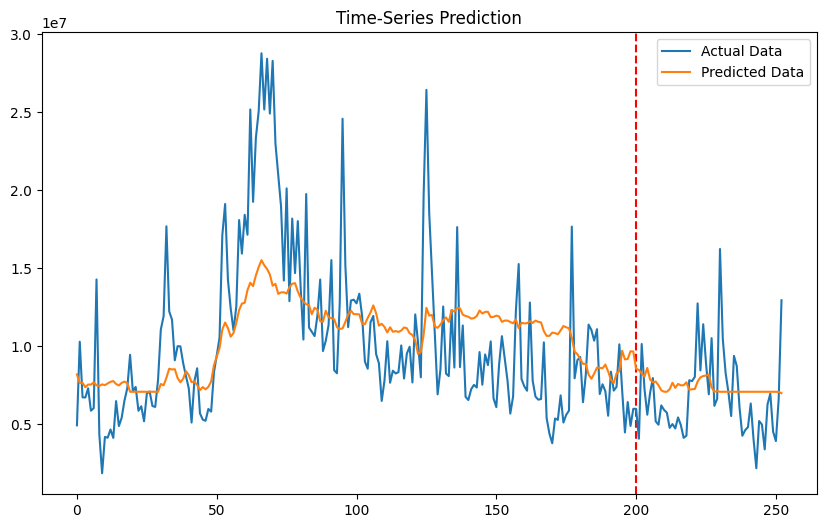

In [14]:
# 코드 7-51 모델 예측 결과 출력
train_predict=model(df_x_ss)
predicted=train_predict.data.numpy()
label_y=df_y_ms.data.numpy()

predicted=ms.inverse_transform(predicted)
label_y=ms.inverse_transform(label_y)
plt.figure(figsize=(10,6))
plt.axvline(x=200,c='r',linestyle='--')

plt.plot(label_y,label='Actual Data')
plt.plot(predicted,label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()